# Notebook 2 — Entraînement des classifieurs comportementaux
*C. elegans* | LabGym dataset

Ce notebook prend en entrée les clips vidéo `.avi` annotés du dataset LabGym,
extrait des features biologiques via le modèle YOLOv8-pose, entraîne trois
classifieurs (Random Forest, Gradient Boosting, LSTM) et choisit le meilleur
modèle à exporter pour le pipeline d'inférence (Notebook 3).

**Prerequis** : le modèle YOLOv8-pose entraîné dans le Notebook 1 (`best.pt`).


## 1. Installation et imports

In [1]:
%pip install ultralytics==8.3.0 -q
# Note : numpy 1.26.4 est déjà présent sur Kaggle — pas besoin de force-reinstall


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, warnings, zipfile
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"]     = "disabled"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import joblib
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("Setup OK")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup OK


## 2. Chemins et configuration

In [3]:
# ─── Chemins Kaggle ─────────────────────────────────────────────────────
import os

MODEL_PATH = "/kaggle/input/models/meriemmelki/yolov8s-pose-c-elegans/pytorch/default/1/best.pt"
TRAIN_ROOT = "/kaggle/input/datasets/meriemmelki/labgym-training-datasets-c-elegans/training datasets/worm locomotion categorizer 22/training/training"
SAVE_DIR   = "/kaggle/working/partie2_outputs"

os.makedirs(SAVE_DIR, exist_ok=True)

# Chargement du modèle YOLOv8-pose
from ultralytics import YOLO
model_pose = YOLO(MODEL_PATH)

classes = sorted([d for d in os.listdir(TRAIN_ROOT)
                  if os.path.isdir(os.path.join(TRAIN_ROOT, d))])

print(f"Dataset : {TRAIN_ROOT}")
print(f"Classes : {classes}")
print(f"Sorties : {SAVE_DIR}")
# Attendu : ['forward crawling', 'immobile', 'omega bend', 'reverse crawling', 'twitching']


Dataset : /kaggle/input/datasets/meriemmelki/labgym-training-datasets-c-elegans/training datasets/worm locomotion categorizer 22/training/training
Classes : ['forward crawling', 'immobile', 'omega bend', 'reverse crawling', 'twitching']
Sorties : /kaggle/working/partie2_outputs


## 3. Fonctions d'extraction de features

Chaque clip est résumé par un vecteur de features biologiques agrégées sur toutes ses frames :
vitesse du centroïde, courbure du corps, élongation et linéarité de la trajectoire.


In [4]:
CONF_THRESHOLD = 0.15   # seuil de détection YOLOv8
VIS_THRESHOLD  = 0.10   # seuil de visibilité keypoint

FEAT_COLS = [
    "speed_mean", "speed_std", "speed_max",
    "curvature_mean", "curvature_std",
    "elongation_mean", "elongation_std",
    "length_mean", "linearity", "detection_rate",
]

def body_curvature(kpts):
    """Angle tête-milieu-queue (degrés). Faible = ver courbé (omega), élevé = ver droit."""
    vis = kpts[kpts[:, 2] > VIS_THRESHOLD, :2]
    if len(vis) < 3:
        return np.nan
    h, m, t = vis[0], vis[len(vis) // 2], vis[-1]
    v1, v2  = m - h, t - m
    cos_a   = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    return float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))

def body_length(kpts):
    """Longueur totale du corps le long des keypoints visibles."""
    vis = kpts[kpts[:, 2] > VIS_THRESHOLD, :2]
    if len(vis) < 2:
        return np.nan
    return float(sum(np.linalg.norm(vis[i+1] - vis[i]) for i in range(len(vis)-1)))

def elongation_ratio(kpts):
    """Rapport distance droite / longueur totale. Proche de 1 = ver allongé."""
    vis = kpts[kpts[:, 2] > VIS_THRESHOLD, :2]
    if len(vis) < 2:
        return np.nan
    return float(np.linalg.norm(vis[0] - vis[-1])) / (body_length(kpts) + 1e-8)

def heading_angle(kpts):
    """Orientation de l'axe tête-queue (0-180 degrés, invariant au retournement)."""
    vis = kpts[kpts[:, 2] > VIS_THRESHOLD, :2]
    if len(vis) < 2:
        return np.nan
    delta = vis[-1] - vis[0]
    return abs(float(np.degrees(np.arctan2(delta[1], delta[0]))))

def extract_clip_features(video_path, model, conf=CONF_THRESHOLD):
    """
    Lit un clip frame par frame et retourne un dict de features agrégées.
    Retourne None si moins de 3 frames valides sont détectées.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    centroids, curvatures, lengths, elongations = [], [], [], []
    n_frames_total = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        n_frames_total += 1

        res = model.predict(source=frame, conf=conf, verbose=False)[0]
        if len(res.boxes) == 0:
            continue

        best = int(res.boxes.conf.argmax())
        kxy  = res.keypoints.xy[best].cpu().numpy()
        kcf  = res.keypoints.conf[best].cpu().numpy()
        kpts = np.concatenate([kxy, kcf.reshape(-1, 1)], axis=1)

        vis = kpts[kpts[:, 2] > VIS_THRESHOLD, :2]
        if len(vis) < 3:
            continue

        centroids.append(vis.mean(axis=0))
        curvatures.append(body_curvature(kpts))
        lengths.append(body_length(kpts))
        elongations.append(elongation_ratio(kpts))

    cap.release()

    if len(centroids) < 3:
        return None

    centroids   = np.array(centroids)
    speeds      = np.linalg.norm(np.diff(centroids, axis=0), axis=1)
    net_disp    = float(np.linalg.norm(centroids[-1] - centroids[0]))
    path_length = float(speeds.sum())
    linearity   = net_disp / (path_length + 1e-8)

    return {
        "speed_mean"    : float(np.mean(speeds)),
        "speed_std"     : float(np.std(speeds)),
        "speed_max"     : float(np.max(speeds)),
        "curvature_mean": float(np.nanmean(curvatures)),
        "curvature_std" : float(np.nanstd(curvatures)),
        "elongation_mean": float(np.nanmean(elongations)),
        "elongation_std" : float(np.nanstd(elongations)),
        "length_mean"   : float(np.nanmean(lengths)),
        "linearity"     : linearity,
        "detection_rate": len(centroids) / max(n_frames_total, 1),
    }

print("Fonctions de features definies")
print(f"Features utilisees : {FEAT_COLS}")

Fonctions de features definies
Features utilisees : ['speed_mean', 'speed_std', 'speed_max', 'curvature_mean', 'curvature_std', 'elongation_mean', 'elongation_std', 'length_mean', 'linearity', 'detection_rate']


## 4. Extraction des features sur le dataset LabGym

On lit chaque clip `.avi` et on calcule son vecteur de features.
Cette étape peut prendre plusieurs minutes selon la taille du dataset.


In [5]:
rows, errors = [], []

for cls in classes:
    cls_dir   = os.path.join(TRAIN_ROOT, cls)
    avi_files = [f for f in os.listdir(cls_dir) if f.endswith(".avi")]

    for fname in tqdm(avi_files, desc=f"[{cls}]", leave=False):
        feat = extract_clip_features(os.path.join(cls_dir, fname), model_pose)
        if feat is None:
            errors.append(fname)
            continue
        feat["label"]    = cls
        feat["filename"] = fname
        rows.append(feat)

df = pd.DataFrame(rows)
df.to_csv(f"{SAVE_DIR}/labgym_features.csv", index=False)

print(f"{len(df)} clips extraits | {len(errors)} ignores (detection insuffisante)")
print(df["label"].value_counts().to_string())

2449 clips extraits | 437 ignores (detection insuffisante)
label
reverse crawling    764
forward crawling    681
omega bend          533
twitching           284
immobile            187


## 5. Visualisation des distributions de features

Avant d'entraîner, on vérifie que les features séparent effectivement les classes.
Si les distributions se chevauchent totalement, aucun classifieur ne pourra bien généraliser.


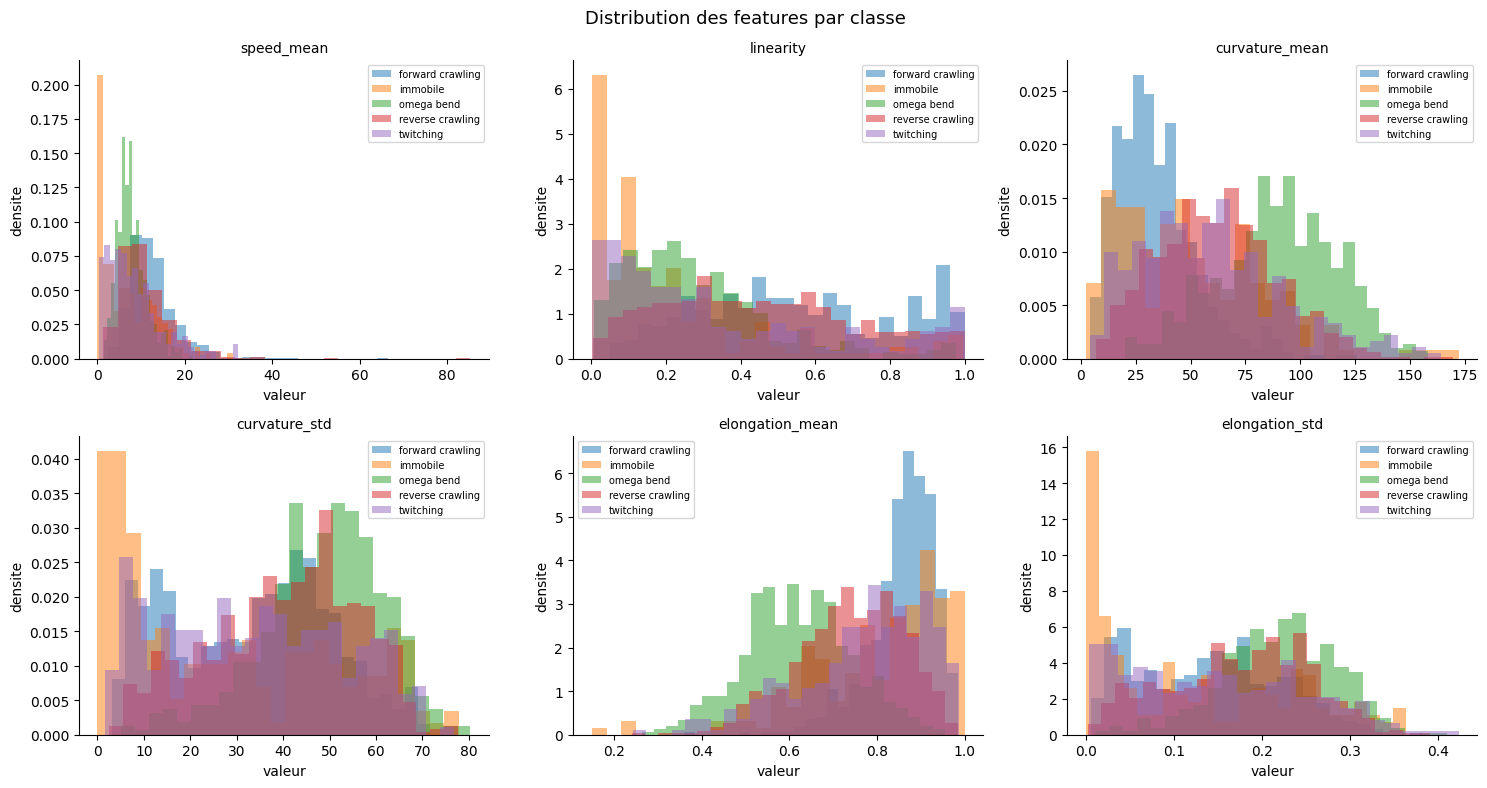

Moyennes par classe :
                  speed_mean  linearity  curvature_mean  curvature_std  elongation_mean  elongation_std
label                                                                                                  
forward crawling      12.815      0.553          34.345         33.135            0.858           0.139
immobile               6.827      0.218          50.191         27.917            0.807           0.123
omega bend             7.868      0.282          90.057         48.449            0.619           0.219
reverse crawling      10.891      0.452          62.488         40.193            0.738           0.175
twitching              8.230      0.335          59.423         33.610            0.768           0.149


In [6]:
KEY_FEATURES = ["speed_mean", "linearity", "curvature_mean", "curvature_std",
                "elongation_mean", "elongation_std"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, KEY_FEATURES):
    for cls in classes:
        vals = df[df["label"] == cls][feat].dropna()
        ax.hist(vals, bins=25, alpha=0.5, label=cls, density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel("valeur")
    ax.set_ylabel("densite")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Distribution des features par classe", fontsize=13)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/feature_distributions.png", dpi=150)
plt.show()

print("Moyennes par classe :")
print(df.groupby("label")[KEY_FEATURES].mean().round(3).to_string())

## 6. Entraînement — Random Forest et Gradient Boosting

Les deux classifieurs travaillent sur les features agrégées par clip.


In [7]:
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])

X = df[FEAT_COLS].values
y = df["label_enc"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Classes : {list(le.classes_)}")

# Random Forest
rf = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                   random_state=42, n_jobs=-1))
])
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Gradient Boosting
gb = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                       learning_rate=0.1, random_state=42))
])
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

for name, y_pred in [("RandomForest", y_pred_rf), ("GradientBoosting", y_pred_gb)]:
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro", zero_division=0)
    print(f"\n=== {name} | Accuracy: {acc:.3f} | F1 macro: {f1:.3f} ===")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Train : (1959, 10)  |  Test : (490, 10)
Classes : ['forward crawling', 'immobile', 'omega bend', 'reverse crawling', 'twitching']

=== RandomForest | Accuracy: 0.686 | F1 macro: 0.632 ===
                  precision    recall  f1-score   support

forward crawling       0.85      0.82      0.83       136
        immobile       0.74      0.54      0.62        37
      omega bend       0.72      0.78      0.74       107
reverse crawling       0.60      0.70      0.65       153
       twitching       0.38      0.26      0.31        57

        accuracy                           0.69       490
       macro avg       0.66      0.62      0.63       490
    weighted avg       0.68      0.69      0.68       490


=== GradientBoosting | Accuracy: 0.688 | F1 macro: 0.624 ===
                  precision    recall  f1-score   support

forward crawling       0.83      0.82      0.82       136
        immobile       0.62      0.43      0.51        37
      omega bend       0.72      0.79      0.75   

## 7. Cross-validation 5-fold

In [8]:
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "f1_macro", "f1_weighted"]

print("=== Cross-validation 5-fold ===\n")
for name, model in [("RandomForest", rf), ("GradientBoosting", gb)]:
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"  {name}")
    print(f"    Accuracy    : {scores['test_accuracy'].mean():.3f} +/- {scores['test_accuracy'].std():.3f}")
    print(f"    F1 macro    : {scores['test_f1_macro'].mean():.3f} +/- {scores['test_f1_macro'].std():.3f}")
    print(f"    F1 weighted : {scores['test_f1_weighted'].mean():.3f} +/- {scores['test_f1_weighted'].std():.3f}\n")

=== Cross-validation 5-fold ===

  RandomForest
    Accuracy    : 0.692 +/- 0.014
    F1 macro    : 0.622 +/- 0.025
    F1 weighted : 0.680 +/- 0.017

  GradientBoosting
    Accuracy    : 0.688 +/- 0.013
    F1 macro    : 0.625 +/- 0.021
    F1 weighted : 0.680 +/- 0.013



## 8. Matrices de confusion et importance des features

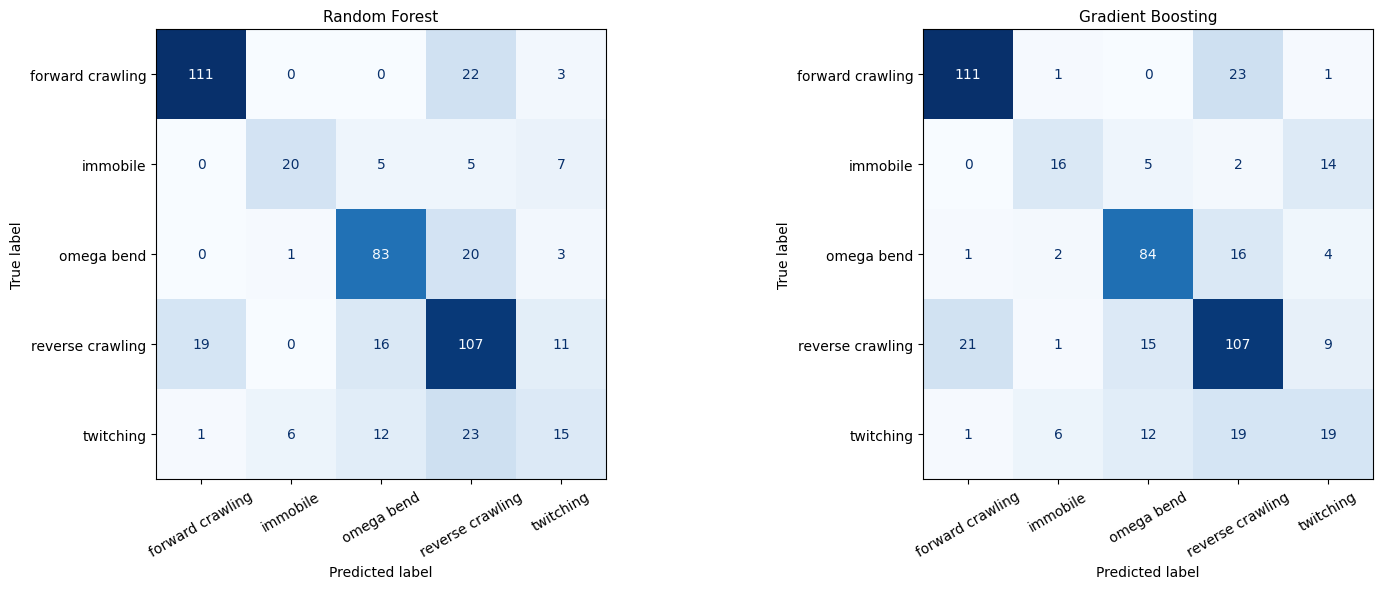

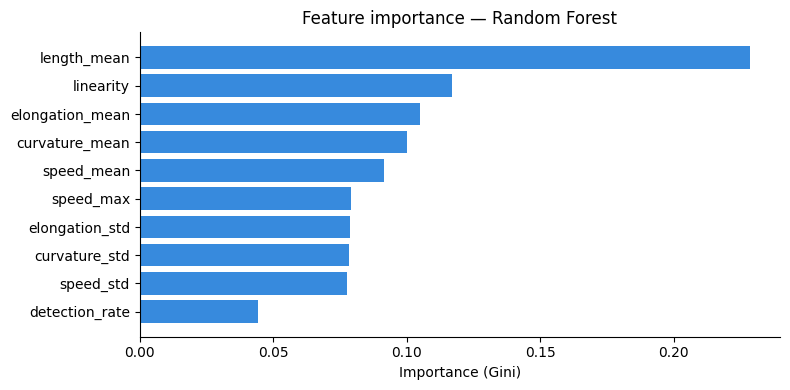

        feature  importance
    length_mean    0.228430
      linearity    0.116967
elongation_mean    0.105027
 curvature_mean    0.099964
     speed_mean    0.091461
      speed_max    0.079295
 elongation_std    0.078557
  curvature_std    0.078363
      speed_std    0.077766
 detection_rate    0.044169


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, y_pred) in zip(axes, [("Random Forest", y_pred_rf), ("Gradient Boosting", y_pred_gb)]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=le.classes_
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrices.png", dpi=150)
plt.show()

# Importance des features (RF)
imp      = rf.named_steps["clf"].feature_importances_
feat_imp = pd.DataFrame({"feature": FEAT_COLS, "importance": imp})
feat_imp = feat_imp.sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1], color="#378ADD")
ax.set_xlabel("Importance (Gini)")
ax.set_title("Feature importance — Random Forest")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/feature_importance.png", dpi=150)
plt.show()
print(feat_imp.to_string(index=False))

## 9. LSTM — classifieur séquentiel

Contrairement au RF/GB qui agrègent les features en un seul vecteur,
le LSTM reçoit la séquence complète de features frame par frame,
ce qui lui permet de capturer la dynamique temporelle du comportement.


In [10]:
MAX_LEN = 12   # longueur de séquence fixe (durée des clips LabGym en frames)

def extract_lstm_sequence(video_path, model, conf=CONF_THRESHOLD, max_len=MAX_LEN):
    """
    Extrait une séquence (max_len, 4) depuis un clip.
    Features par frame : [curvature, elongation, speed, heading_angle].
    Retourne None si moins de 3 frames valides.
    """
    cap    = cv2.VideoCapture(video_path)
    seq    = []
    prev_c = None

    while True:
        ret, frame = cap.read()
        if not ret or len(seq) >= max_len:
            break

        res = model.predict(source=frame, conf=conf, verbose=False)[0]
        if len(res.boxes) == 0:
            continue

        best = int(res.boxes.conf.argmax())
        kxy  = res.keypoints.xy[best].cpu().numpy()
        kcf  = res.keypoints.conf[best].cpu().numpy()
        kpts = np.concatenate([kxy, kcf.reshape(-1, 1)], axis=1)

        vis = kpts[kpts[:, 2] > VIS_THRESHOLD, :2]
        if len(vis) < 3:
            continue

        cx, cy = vis.mean(axis=0)
        spd    = float(np.linalg.norm([cx, cy] - prev_c)) if prev_c is not None else 0.0
        prev_c = np.array([cx, cy])

        seq.append([
            body_curvature(kpts) or 0.0,
            elongation_ratio(kpts) or 0.0,
            spd,
            heading_angle(kpts) or 0.0,
        ])

    cap.release()

    if len(seq) < 3:
        return None

    seq = np.array(seq, dtype=np.float32)
    if len(seq) < max_len:
        seq = np.vstack([seq, np.zeros((max_len - len(seq), 4), dtype=np.float32)])
    return seq[:max_len]


# Extraction des sequences
seqs, labels_lstm = [], []

for cls in classes:
    cls_dir   = os.path.join(TRAIN_ROOT, cls)
    avi_files = [f for f in os.listdir(cls_dir) if f.endswith(".avi")]
    label_idx = le.transform([cls])[0]

    for fname in tqdm(avi_files, desc=f"[{cls}]", leave=False):
        seq = extract_lstm_sequence(os.path.join(cls_dir, fname), model_pose)
        if seq is not None:
            seqs.append(seq)
            labels_lstm.append(label_idx)

X_seq = np.array(seqs, dtype=np.float32)
y_seq = np.array(labels_lstm, dtype=np.int64)
print(f"{len(X_seq)} sequences | shape : {X_seq.shape}")

2449 sequences | shape : (2449, 12, 4)


In [11]:
# Normalisation et split
N, T, F     = X_seq.shape
scaler_lstm = StandardScaler()
X_flat      = scaler_lstm.fit_transform(X_seq.reshape(-1, F)).reshape(N, T, F)

tr_idx, te_idx = train_test_split(
    np.arange(N), test_size=0.2, random_state=42, stratify=y_seq
)

X_tr_l = torch.tensor(X_flat[tr_idx])
y_tr_l = torch.tensor(y_seq[tr_idx])
X_te_l = torch.tensor(X_flat[te_idx])
y_te_l = torch.tensor(y_seq[te_idx])

loader = DataLoader(TensorDataset(X_tr_l, y_tr_l), batch_size=32, shuffle=True)

# Architecture
class BehaviorLSTM(nn.Module):
    def __init__(self, input_size=4, hidden=64, n_layers=2, n_classes=5, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, n_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_classes = len(le.classes_)
lstm_model = BehaviorLSTM(n_classes=n_classes).to(device)

counts    = np.bincount(y_seq)
weights   = torch.tensor(1.0 / (counts + 1e-8), dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"Device : {device} | Classes : {n_classes}")

Device : cuda | Classes : 5


Epoch  10/60 | Loss : 1.1971 | Val Acc : 0.594
Epoch  20/60 | Loss : 1.1048 | Val Acc : 0.586
Epoch  30/60 | Loss : 1.0339 | Val Acc : 0.565
Epoch  40/60 | Loss : 0.9444 | Val Acc : 0.612
Epoch  50/60 | Loss : 0.8358 | Val Acc : 0.592
Epoch  60/60 | Loss : 0.7257 | Val Acc : 0.576


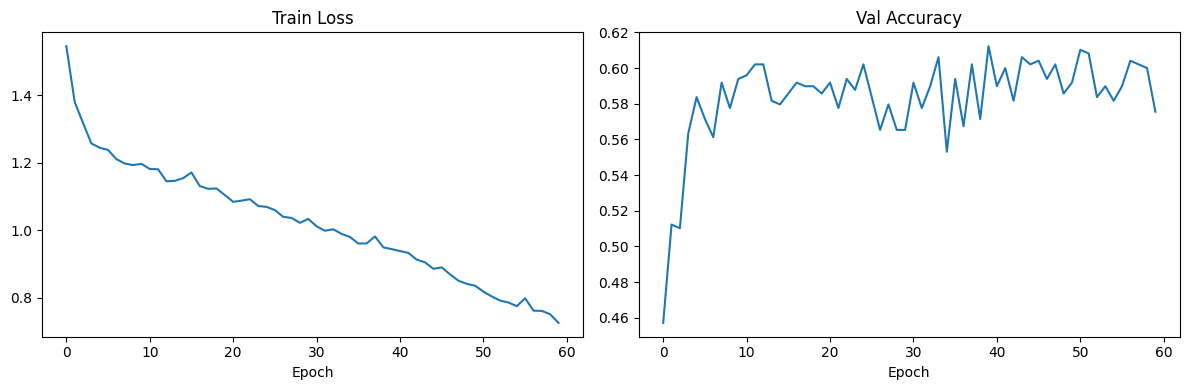


=== LSTM — Rapport final (test set) ===
                  precision    recall  f1-score   support

forward crawling       0.77      0.69      0.73       136
        immobile       0.40      0.49      0.44        37
      omega bend       0.58      0.65      0.61       107
reverse crawling       0.63      0.50      0.56       153
       twitching       0.29      0.40      0.34        57

        accuracy                           0.58       490
       macro avg       0.53      0.55      0.54       490
    weighted avg       0.60      0.58      0.58       490



In [12]:
EPOCHS = 60
train_losses, val_accs = [], []

for epoch in range(EPOCHS):
    lstm_model.train()
    epoch_loss = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(lstm_model(Xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    lstm_model.eval()
    with torch.no_grad():
        preds   = lstm_model(X_te_l.to(device)).argmax(dim=1).cpu().numpy()
        val_acc = accuracy_score(y_te_l.numpy(), preds)

    train_losses.append(epoch_loss / len(loader))
    val_accs.append(val_acc)
    scheduler.step(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss : {epoch_loss/len(loader):.4f} | Val Acc : {val_acc:.3f}")

# Courbes d'entrainement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses); ax1.set_title("Train Loss"); ax1.set_xlabel("Epoch")
ax2.plot(val_accs);     ax2.set_title("Val Accuracy"); ax2.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/lstm_training_curves.png", dpi=150)
plt.show()

print("\n=== LSTM — Rapport final (test set) ===")
print(classification_report(y_te_l.numpy(), preds, target_names=le.classes_, zero_division=0))

## 10. Comparaison et choix du meilleur modèle

On compare les trois modèles sur leur test set respectif, puis on choisit
celui qui sera utilisé dans le Notebook 3 pour l'inférence.


In [13]:
lstm_model.eval()
with torch.no_grad():
    preds_lstm = lstm_model(X_te_l.to(device)).argmax(dim=1).cpu().numpy()

results = {
    "RandomForest" : (y_test,        y_pred_rf),
    "GradientBoost": (y_test,        y_pred_gb),
    "LSTM"         : (y_te_l.numpy(), preds_lstm),
}

print(f"{'Modele':<20} {'Accuracy':>10} {'F1 macro':>10} {'F1 weighted':>12}")
print("-" * 55)

scores = {}
for name, (yt, yp) in results.items():
    acc = accuracy_score(yt, yp)
    f1m = f1_score(yt, yp, average="macro",    zero_division=0)
    f1w = f1_score(yt, yp, average="weighted", zero_division=0)
    scores[name] = {"acc": acc, "f1_macro": f1m, "f1_weighted": f1w}
    print(f"{name:<20} {acc:>10.3f} {f1m:>10.3f} {f1w:>12.3f}")

# Choix automatique du meilleur modele (F1 macro)
best_name = max(scores, key=lambda n: scores[n]["f1_macro"])
print(f"\nMeilleur modele (F1 macro) : {best_name}")

Modele                 Accuracy   F1 macro  F1 weighted
-------------------------------------------------------
RandomForest              0.686      0.632        0.679
GradientBoost             0.688      0.624        0.682
LSTM                      0.576      0.536        0.583

Meilleur modele (F1 macro) : RandomForest


## 11. Sauvegarde des artefacts

In [14]:
# Sauvegarde des classifieurs et du label encoder
joblib.dump(rf,   f"{SAVE_DIR}/rf_labgym.pkl")
joblib.dump(gb,   f"{SAVE_DIR}/gb_labgym.pkl")
joblib.dump(le,   f"{SAVE_DIR}/le_labgym.pkl")

# Sauvegarde du LSTM et de son scaler
joblib.dump(scaler_lstm, f"{SAVE_DIR}/scaler_lstm.pkl")
torch.save(lstm_model.state_dict(), f"{SAVE_DIR}/lstm_behavior.pt")

# Configuration exportee pour le Notebook 3
import json
config = {
    "best_model"     : best_name,          # modele recommande pour l'inference
    "conf_threshold" : CONF_THRESHOLD,     # seuil YOLOv8
    "feat_cols"      : FEAT_COLS,          # features attendues par RF/GB
    "classes"        : list(le.classes_),  # ordre des classes
    "lstm_max_len"   : MAX_LEN,
}
with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Artefacts sauvegardes dans :", SAVE_DIR)
for fname in ["rf_labgym.pkl", "gb_labgym.pkl", "le_labgym.pkl",
              "scaler_lstm.pkl", "lstm_behavior.pt", "config.json"]:
    path = f"{SAVE_DIR}/{fname}"
    ok   = "OK" if os.path.exists(path) else "MANQUANT"
    print(f"  [{ok}] {fname}")

Artefacts sauvegardes dans : /kaggle/working/partie2_outputs
  [OK] rf_labgym.pkl
  [OK] gb_labgym.pkl
  [OK] le_labgym.pkl
  [OK] scaler_lstm.pkl
  [OK] lstm_behavior.pt
  [OK] config.json
